In [5]:
# codigo inicial que unificou as bases de vendas e vistoria, criou as colunas de ágio absoluto e percentual, 
# e removeu os registros duplicados dos itens agrupados

# import pandas as pd
# pd.set_option("display.float_format", lambda x: f"{x:.2f}")

# tabela = pd.read_csv("Vendas_NOVO_AREAS.csv", sep=";", encoding="latin-1")
# vistoria = pd.read_csv("Vistoria.csv", sep=";", encoding="latin-1")

# tabela = tabela.merge(
#     vistoria[["CD_IMOVEL_URBANO", "SIM_SITIMO_DS"]],
#     how="left",
#     left_on="CD_IMOVEL",
#     right_on="CD_IMOVEL_URBANO"
# )

# # remove a coluna duplicada da chave
# tabela = tabela.drop(columns=["CD_IMOVEL_URBANO"])
# tabela = tabela.rename(columns={"SIM_SITIMO_DS": "SITUACAO_VISTORIA"})
# tabela["SITUACAO_VISTORIA"] = tabela["SITUACAO_VISTORIA"].fillna("SEM_VISTORIA")

# tabela = tabela.drop(columns=["CD_IMOVEL"])

# # colunas que definem a duplicidade: mesmo ano, mesmo edital e mesmo item do edital (item de edital com imoveis agrupados)
# cols = ["ANO_VENDA", "EDITAL_VENDA", "ITEM_EDITAL"]
# # máscara: True para linhas que aparecem em duplicidade (em qualquer posição do grupo)
# mask_dup = tabela.duplicated(subset=cols, keep=False)
# # remove TODAS as linhas duplicadas desses grupos
# tabela_sem_dups = tabela.loc[~mask_dup].copy()

# # Foram removidos 157 itens que constavam como items agrupados, de um total de 2978, restando 2821 registros 
# # print("Linhas originais:", len(tabela))
# # print("Linhas removidas:", mask_dup.sum())
# # print("Linhas finais:", len(tabela_sem_dups))

# tabela = tabela_sem_dups

# #criacao da coluna AGIO ABSOLUTO , esta coluna deve ser retirada do treino
# tabela["AGIO_ABSOLUTO"] = tabela["VALOR_VENDA"] - tabela["VALOR_LAUDO"]
# tabela["AGIO_PERCENTUAL"] = ((tabela["VALOR_VENDA"] - tabela["VALOR_LAUDO"]) / tabela["VALOR_LAUDO"]) * 100

# tabela
# tabela.to_csv('dados.csv', sep=";", index=False, encoding='utf-8')
# tabela.describe()


In [1]:
# leitura da base de dados já processada, com as colunas de ágio absoluto e percentual, e sem os registros duplicados dos itens agrupados
import pandas as pd
tabela = pd.read_csv("dados.csv", sep=";", encoding="utf-8")
# tabela["CIDADE"].unique()

In [14]:
# Análises descritivas:

# analise para ver a tabela ordenada pelo maior valor de venda 
# tabela_ordenada = tabela.sort_values("VALOR_VENDA", ascending=False).reset_index(drop=True)

# Exportacao para o Excel
# tabela.to_excel("vendas.xlsx", index=False)

# Analise dos maiores valores, menores valores, médias e desvio padrão para as colunas de valor de avaliação, valor de venda e quantidade de ofertas

print(f"Maior Valor de Avaliaçao: {tabela['VALOR_LAUDO'].max():.2f}")
print(f"Menor Valor de Avaliação: {tabela['VALOR_LAUDO'].min():.2f}")
print(f"Média do Valor da Avaliação: {tabela['VALOR_LAUDO'].mean():.2f}")
print(f"Desvio Padrão do Valor da Avaliação: {tabela['VALOR_LAUDO'].std():.2f}")

print(f"Maior Valor de Venda: {tabela['VALOR_VENDA'].max():.2f}")
print(f"Menor Valor de Venda: {tabela['VALOR_VENDA'].min():.2f}")
print(f"Média do Valor da Venda: {tabela['VALOR_VENDA'].mean():.2f}")
print(f"Desvio Padrão do Valor da Venda: {tabela['VALOR_VENDA'].std():.2f}")

print(f"Maior Qtd de Ofertas: {tabela['QTD_OFERTAS'].max():.2f}")
print(f"Menor Qtd de Ofertas: {tabela['QTD_OFERTAS'].min():.2f}")
print(f"Média da Qtd de Ofertas: {tabela['QTD_OFERTAS'].mean():.2f}")
print(f"Desvio Padrão da Qtd de Ofertas: {tabela['QTD_OFERTAS'].std():.2f}")

agio_medio_abs = tabela["AGIO_ABSOLUTO"].mean()
agio_medio_pct = tabela["AGIO_PERCENTUAL"].mean()
print(f"Ágio médio absoluto: {agio_medio_abs:,.2f}")
print(f"Ágio médio percentual: {agio_medio_pct:.2f}%")


mediana_valor_laudо = tabela["VALOR_LAUDO"].median()
mediana_valor_venda = tabela["VALOR_VENDA"].median()
agio_mediano_abs = tabela["AGIO_ABSOLUTO"].median()
agio_mediano_pct = tabela["AGIO_PERCENTUAL"].median()

# print("MEDIANAS")
print(f"Mediana do Valor de Avaliação: {mediana_valor_laudо:,.2f}")
print(f"Mediana do Valor de Venda: {mediana_valor_venda:,.2f}")
print(f"Ágio mediano absoluto: {agio_mediano_abs:,.2f}")
print(f"Ágio mediano percentual: {agio_mediano_pct:.2f}%")

# 2) Quartis
quartis_valor_laudo = tabela["VALOR_LAUDO"].quantile([0.25, 0.50, 0.75])
quartis_valor_venda = tabela["VALOR_VENDA"].quantile([0.25, 0.50, 0.75])
quartis_agio_percentual = tabela["AGIO_PERCENTUAL"].quantile([0.25, 0.50, 0.75])
quartis_agio_absoluto = tabela["AGIO_ABSOLUTO"].quantile([0.25, 0.50, 0.75])

# print("QUARTIS")
print(f"Quartis do Valor de Avaliação: {quartis_valor_laudo}")
print(f"Quartis do Valor de Venda: {quartis_valor_venda}")
print(f"Quartis do Ágio Percentual: {quartis_agio_percentual}")
print(f"Quartis do Ágio Absoluto: {quartis_agio_absoluto}")

# 3) Coeficiente de variação = (desvio padrão / média) * 100
cv_valor_laudo = (tabela["VALOR_LAUDO"].std() / tabela["VALOR_LAUDO"].mean()) * 100
cv_valor_venda = (tabela["VALOR_VENDA"].std() / tabela["VALOR_VENDA"].mean()) * 100
cv_qtd_ofertas = (tabela["QTD_OFERTAS"].std() / tabela["QTD_OFERTAS"].mean()) * 100
cv_agio_absoluto = (tabela["AGIO_ABSOLUTO"].std() / tabela["AGIO_ABSOLUTO"].mean()) * 100
cv_agio_percentual = (tabela["AGIO_PERCENTUAL"].std() / tabela["AGIO_PERCENTUAL"].mean()) * 100

print(cv_valor_laudo, cv_valor_venda, cv_qtd_ofertas, cv_agio_absoluto, cv_agio_percentual)

percentual_acima_avaliacao = (tabela["AGIO_ABSOLUTO"] > 0).mean() * 100
print(f"Percentual de vendas acima do valor de avaliação: {percentual_acima_avaliacao:.2f}%")

corr_ofertas_agio_abs = tabela["QTD_OFERTAS"].corr(tabela["AGIO_ABSOLUTO"])
corr_ofertas_agio_pct = tabela["QTD_OFERTAS"].corr(tabela["AGIO_PERCENTUAL"])

print(f"Correlação entre quantidade de ofertas e ágio absoluto: {corr_ofertas_agio_abs:.4f}")
print(f"Correlação entre quantidade de ofertas e ágio percentual: {corr_ofertas_agio_pct:.4f}")

Maior Valor de Avaliaçao: 353000000.00
Menor Valor de Avaliação: 2412.00
Média do Valor da Avaliação: 978713.85
Desvio Padrão do Valor da Avaliação: 7056496.58
Maior Valor de Venda: 406670000.00
Menor Valor de Venda: 3800.00
Média do Valor da Venda: 1247612.42
Desvio Padrão do Valor da Venda: 8323860.91
Maior Qtd de Ofertas: 52.00
Menor Qtd de Ofertas: 1.00
Média da Qtd de Ofertas: 3.12
Desvio Padrão da Qtd de Ofertas: 4.06
Ágio médio absoluto: 268,898.57
Ágio médio percentual: 29.82%
Mediana do Valor de Avaliação: 284,500.00
Mediana do Valor de Venda: 329,850.00
Ágio mediano absoluto: 33,999.50
Ágio mediano percentual: 14.92%
Quartis do Valor de Avaliação: 0.25   127042.50
0.50   284500.00
0.75   493750.00
Name: VALOR_LAUDO, dtype: float64
Quartis do Valor de Venda: 0.25   157584.75
0.50   329850.00
0.75   639625.00
Name: VALOR_VENDA, dtype: float64
Quartis do Ágio Percentual: 0.25    3.03
0.50   14.92
0.75   40.13
Name: AGIO_PERCENTUAL, dtype: float64
Quartis do Ágio Absoluto: 0.25  

In [2]:
# Analisar correlação entre as variáveis numéricas e a variável target "VALOR_VENDA"

colunas = [
    "VALOR_LAUDO",
    "AREA_MAX_CONSTR",
    "AREA_BASE",
    "AREA",
    "QTD_OFERTAS",
    "AGIO_ABSOLUTO",
    "AGIO_PERCENTUAL",
    "VALOR_VENDA"   # target Y
]

# cria um dataframe apenas com essas colunas
df_corr = tabela[colunas].copy()

# calcula a matriz de correlação
matriz_corr = df_corr.corr(method="pearson")
# correlação de todas as variáveis com a target
corr_com_y = matriz_corr["VALOR_VENDA"].sort_values(ascending=False)

display(matriz_corr)
corr_com_y_df = corr_com_y.reset_index()
corr_com_y_df.columns = ["Variavel", "Correlacao_com_VALOR_VENDA"]

display(corr_com_y_df)

,VALOR_LAUDO,AREA_MAX_CONSTR,AREA_BASE,AREA,QTD_OFERTAS,AGIO_ABSOLUTO,AGIO_PERCENTUAL,VALOR_VENDA
VALOR_LAUDO,1.000000,0.855826,0.952286,0.837078,-0.012225,0.792615,-0.006581,0.993679
AREA_MAX_CONSTR,0.855826,1.000000,0.950299,0.949494,-0.026462,0.666965,0.000140,0.848322
AREA_BASE,0.952286,0.950299,1.000000,0.946794,-0.015737,0.744487,0.002822,0.944368
AREA,0.837078,0.949494,0.946794,1.000000,-0.016886,0.693239,0.008618,0.837266
QTD_OFERTAS,-0.012225,-0.026462,-0.015737,-0.016886,1.000000,0.086564,0.459889,0.005574
AGIO_ABSOLUTO,0.792615,0.666965,0.744487,0.693239,0.086564,1.000000,0.202961,0.856053
AGIO_PERCENTUAL,-0.006581,0.000140,0.002822,0.008618,0.459889,0.202961,1.000000,0.031790
VALOR_VENDA,0.993679,0.848322,0.944368,0.837266,0.005574,0.856053,0.031790,1.000000


,Variavel,Correlacao_com_VALOR_VENDA
0,VALOR_VENDA,1.000000
1,VALOR_LAUDO,0.993679
2,AREA_BASE,0.944368
3,AGIO_ABSOLUTO,0.856053
4,AREA_MAX_CONSTR,0.848322
5,AREA,0.837266
6,AGIO_PERCENTUAL,0.031790
7,QTD_OFERTAS,0.005574


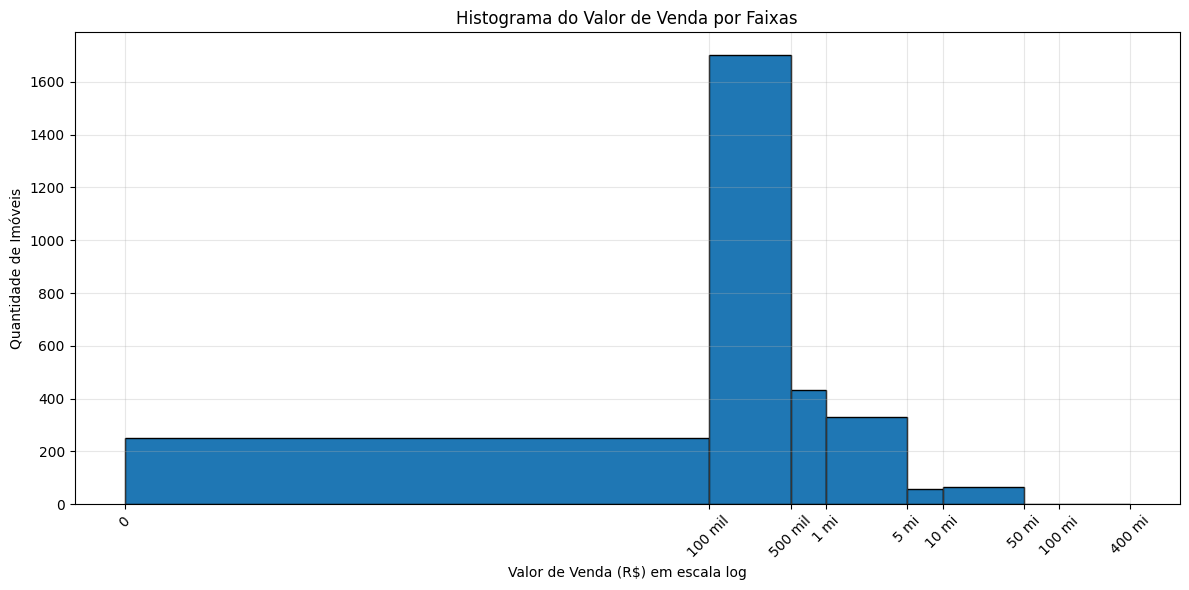

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# faixas no valor original
faixas_valor = [
    0,
    100_000,
    500_000,
    1_000_000,
    5_000_000,
    10_000_000,
    50_000_000,
    100_000_000,
    400_000_000
]

# converter as faixas para escala log
faixas_log = np.log1p(faixas_valor)

# dados transformados em log
dados_log = np.log1p(tabela["VALOR_VENDA"].dropna())

plt.figure(figsize=(12, 6))
plt.hist(dados_log, bins=faixas_log, edgecolor="black")

plt.title("Histograma do Valor de Venda por Faixas")
plt.xlabel("Valor de Venda (R$) em escala log")
plt.ylabel("Quantidade de Imóveis")
plt.grid(True, alpha=0.3)

# mostrar no eixo X os valores originais, não o log
plt.xticks(
    faixas_log,
    [
        "0",
        "100 mil",
        "500 mil",
        "1 mi",
        "5 mi",
        "10 mi",
        "50 mi",
        "100 mi",
        "400 mi"
    ],
    rotation=45
)

plt.tight_layout()
plt.show()

In [4]:
# y -> é a coluna da base de dados que eu quero prever
y = tabela["VALOR_VENDA"]

# x -> as colunas da base de dados que eu vou usar pra fazer a previsão
X = tabela.drop(columns=["VALOR_VENDA", "AGIO_ABSOLUTO", "AGIO_PERCENTUAL"])


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, mean_absolute_percentage_error

from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# identificar tipos de colunas
num_cols = X_treino.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in X_treino.columns if c not in num_cols]

# preprocessamento
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

# modelos de REGRESSÃO
modelo_rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

modelo_knn = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", KNeighborsRegressor(n_neighbors=10))
])

# treinar
modelo_rf.fit(X_treino, y_treino)
modelo_knn.fit(X_treino, y_treino)

# avaliar
def avaliar(nome, modelo):
    pred = modelo.predict(X_teste)
    mape = mean_absolute_percentage_error(y_teste, pred)
    mae = mean_absolute_error(y_teste, pred)
    rmse = root_mean_squared_error(y_teste, pred)
    r2 = r2_score(y_teste, pred)
    print(f"\n== {nome} ==")
    print("MAPE:", mape)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R²:", r2)

avaliar("RandomForestRegressor", modelo_rf)
avaliar("KNeighborsRegressor", modelo_knn)


== RandomForestRegressor ==
MAPE: 0.11785877129401189
MAE: 152858.48309136264
RMSE: 635944.5738052719
R²: 0.9645852188023477

== KNeighborsRegressor ==
MAPE: 0.17279761366991717
MAE: 220987.2262934272
RMSE: 897687.2915236248
R²: 0.9294338887960294


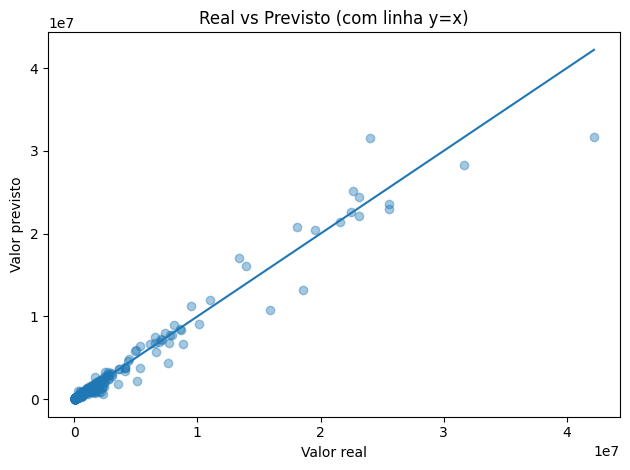

In [5]:
import matplotlib.pyplot as plt
# from cycler import cycler

# cores = plt.get_cmap('tab20b').colors
# ciclo_cores = cycler('color', cores)
# plt.rc('axes', prop_cycle=ciclo_cores)

y_pred = modelo_rf.predict(X_teste)

plt.figure()
plt.scatter(y_teste, y_pred, alpha=0.4)

mx = max(y_teste.max(), y_pred.max())
plt.plot([0, mx], [0, mx])  # linha y = x (perfeito)

plt.title("Real vs Previsto (com linha y=x)")
plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.tight_layout()
plt.show()

In [6]:
import numpy as np

# previsões do modelo no conjunto de teste
y_pred = modelo_rf.predict(X_teste)

# dataframe comparativo: traz as linhas originais do teste
comparacao = tabela.loc[X_teste.index].copy()

comparacao = comparacao.drop(columns=["COD_DESTINACAO_IMOVEL", "EDITAL_VENDA", "ITEM_EDITAL", "VALOR_VENDA", "AREA_MAX_CONSTR", "AREA_BASE", "AREA"])  # remove a coluna de valor real para evitar confusão

# adiciona colunas de comparação
comparacao["VALOR_REAL"] = y_teste
comparacao["VALOR_PREVISTO"] = y_pred
comparacao["ERRO"] = comparacao["VALOR_REAL"] - comparacao["VALOR_PREVISTO"]
comparacao["ERRO_ABS"] = comparacao["ERRO"].abs()
comparacao["ERRO_PCT"] = ((comparacao["ERRO_ABS"] / comparacao["VALOR_REAL"]) * 100).round(2)
# comparacao["ERRO_PCT"] = comparacao["ERRO_PCT"].map(lambda x: f"{x:.2f}%")


# ver as piores previsões (maior erro absoluto)
comparacao.sort_values("ERRO_PCT", ascending=False).head(50)

,SETOR,CIDADE,ANO_VENDA,VALOR_LAUDO,QTD_OFERTAS,SITUACAO_VISTORIA,AGIO_ABSOLUTO,AGIO_PERCENTUAL,VALOR_REAL,VALOR_PREVISTO,ERRO,ERRO_ABS,ERRO_PCT
1110,SETOR INDUSTRIAL I,CEILANDIA,2022,294000,2,OCUPADO,1000.00,0.34,295000.00,1030554.57,-735554.57,735554.57,249.34
168,SETOR DE MATERIAL DE CONSTRUCAO,CEILANDIA,2020,39400,3,OCUPADO,2600.00,6.60,42000.00,96856.58,-54856.58,54856.58,130.61
1340,SETOR DE MATERIAL DE CONSTRUCAO,CEILANDIA,2023,294000,2,CERCADO,204000.50,69.39,498000.50,938372.08,-440371.58,440371.58,88.43
557,SETOR N NORTE-QUADRA COMERCIAL,CEILANDIA,2021,383000,15,OBSTRUIDO,1967100.00,513.60,2350100.00,605029.19,1745070.81,1745070.81,74.26
841,SETOR P NORTE-ENTREQUADRA,CEILANDIA,2021,59700,4,VAGO,6400.00,10.72,66100.00,108418.09,-42318.09,42318.09,64.02
1598,SETOR DE HAB COLETIVAS SUDOESTE,BRASILIA,2023,645000,5,VAGO,1515000.00,234.88,2160000.00,833651.91,1326348.09,1326348.09,61.41
2570,QS-SAMAMBAIA,SAMAMBAIA,2025,166000,10,OCUPADO,434000.00,261.45,600000.00,240183.59,359816.41,359816.41,59.97
1553,SETOR DE HAB COLETIVAS SUDOESTE,BRASILIA,2023,614000,9,VAGO,1439000.00,234.36,2053000.00,852964.49,1200035.51,1200035.51,58.45
2102,SETOR O NORTE-QUADRA RESIDENCIAL,CEILANDIA,2024,1310000,9,OCUPADO,3790000.00,289.31,5100000.00,2174291.18,2925708.82,2925708.82,57.37
463,HABITACIONAL RIACHO FUNDO II,RIACHO FUNDO II,2021,431000,15,VAGO,1279000.00,296.75,1710000.00,736260.18,973739.82,973739.82,56.94


In [7]:
# maiores acertos (menor erro absoluto)
comparacao.sort_values("ERRO_PCT", ascending=True).head(50)

,SETOR,CIDADE,ANO_VENDA,VALOR_LAUDO,QTD_OFERTAS,SITUACAO_VISTORIA,AGIO_ABSOLUTO,AGIO_PERCENTUAL,VALOR_REAL,VALOR_PREVISTO,ERRO,ERRO_ABS,ERRO_PCT
1926,SETOR RESID INDUSTRIA E ABASTECIMENTO,GUARA,2024,308000,4,VAGO,124014.77,40.26,432014.77,432021.97,-7.20,7.20,0.00
2547,COMP. URB. ALDEIAS DO CERRADO - QR 04 - RESIDE...,JARDIM BOTÂNICO,2025,317000,1,VAGO,1200.00,0.38,318200.00,318202.91,-2.91,2.91,0.00
2599,RECANTO DAS EMAS,RECANTO DAS EMAS,2025,146000,1,VAGO,5000.00,3.42,151000.00,150913.81,86.19,86.19,0.06
2110,COMP. URB. ALDEIAS DO CERRADO - QR 02 - RESIDE...,JARDIM BOTÂNICO,2024,301000,2,VAGO,11001.00,3.65,312001.00,312209.85,-208.85,208.85,0.07
1575,COMP. URB. ALDEIAS DO CERRADO - QR 02 - RESIDE...,JARDIM BOTÂNICO,2023,304000,1,VAGO,4389.00,1.44,308389.00,308187.68,201.32,201.32,0.07
1105,BAIRRO SÃO BARTOLOMEU,SAO SEBASTIAO,2022,470000,1,CERCADO,11000.80,2.34,481000.80,481446.62,-445.82,445.82,0.09
2580,QS-SAMAMBAIA,SAMAMBAIA,2025,216000,1,VAGO,47013.00,21.77,263013.00,262761.67,251.33,251.33,0.10
2721,COMP. URB. ALDEIAS DO CERRADO - QR 04 - RESIDE...,JARDIM BOTÂNICO,2025,317000,1,VAGO,777.77,0.25,317777.77,318148.01,-370.24,370.24,0.12
2480,COMP. URB. ALDEIAS DO CERRADO - QR 04 - RESIDE...,JARDIM BOTÂNICO,2025,317000,1,VAGO,4101.01,1.29,321101.01,320582.36,518.65,518.65,0.16
1945,QS-SAMAMBAIA,SAMAMBAIA,2024,121000,1,VAGO,16000.00,13.22,137000.00,137240.22,-240.22,240.22,0.18


In [ ]:
# avaliar o impacto do laudo na previsão (comparar com e sem a coluna de laudo)

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

def avaliar_modelo(df, drop_cols=None, random_state=42):
    drop_cols = drop_cols or []

    # y e X
    y = df["VALOR_VENDA"]
    X = df.drop(columns=["VALOR_VENDA"] + drop_cols)

    # split
    X_treino, X_teste, y_treino, y_teste = train_test_split(
        X, y, test_size=0.3, random_state=random_state
    )

    # detectar colunas por tipo (depois do drop)
    num_cols = X_treino.select_dtypes(include=["number"]).columns.tolist()
    cat_cols = [c for c in X_treino.columns if c not in num_cols]

    # preprocess (recriado a cada chamada)
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocess = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, num_cols),
            ("cat", categorical_transformer, cat_cols),
        ],
        remainder="drop"
    )

    # modelo
    modelo = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=random_state,
            n_jobs=-1
        ))
    ])

    # treinar / prever
    modelo.fit(X_treino, y_treino)
    pred = modelo.predict(X_teste)

    # métricas
    mae = mean_absolute_error(y_teste, pred)
    rmse = root_mean_squared_error(y_teste, pred)
    r2 = r2_score(y_teste, pred)

    return mae, rmse, r2

# A) com laudo
mae_a, rmse_a, r2_a = avaliar_modelo(tabela, drop_cols=["AGIO_ABSOLUTO", "AGIO_PERCENTUAL"])
print("COM LAUDO  -> MAE:", mae_a, "| RMSE:", rmse_a, "| R²:", r2_a)

# B) sem qtd oferta (ajuste o nome se necessário)
mae_b, rmse_b, r2_b = avaliar_modelo(tabela, drop_cols=["QTD_OFERTAS", "AGIO_ABSOLUTO", "AGIO_PERCENTUAL"])
print("SEM QTDE OFERTAS  -> MAE:", mae_b, "| RMSE:", rmse_b, "| R²:", r2_b)

COM LAUDO  -> MAE: 152858.48309136264 | RMSE: 635944.5738052719 | R²: 0.9645852188023477
SEM QTDE OFERTAS  -> MAE: 178294.82943309122 | RMSE: 703917.3655694738 | R²: 0.9566100260385877


: 